
Columns in dataset:
Index(['date', 'total_news', 'rumor_news', 'non_rumor_news'], dtype='object')

Running simulation for: News Dataset: Real vs DK-MT Model


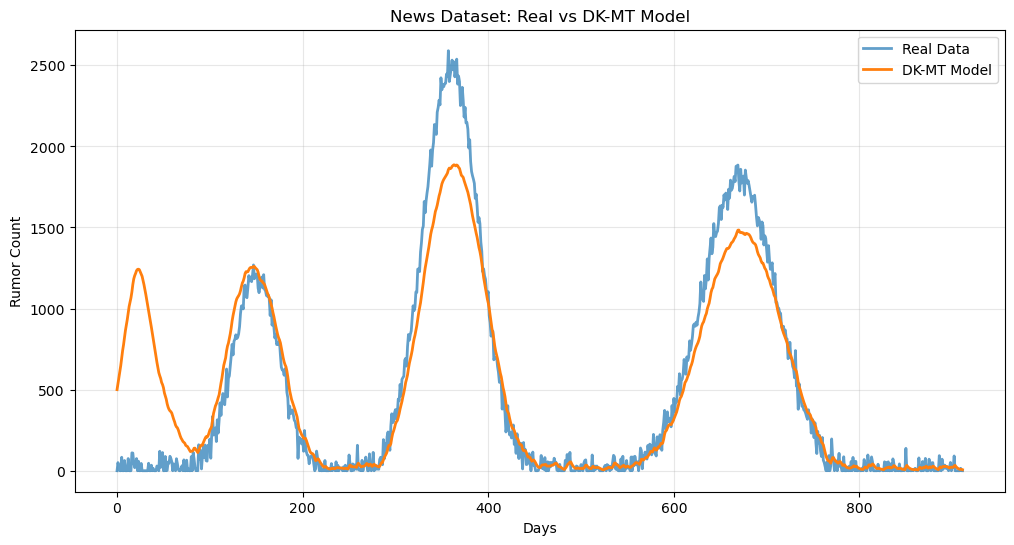


Columns in dataset:
Index(['date', 'total_tweets', 'rumor_tweets', 'non_rumor_tweets'], dtype='object')

Running simulation for: Twitter Dataset: Real vs DK-MT Model


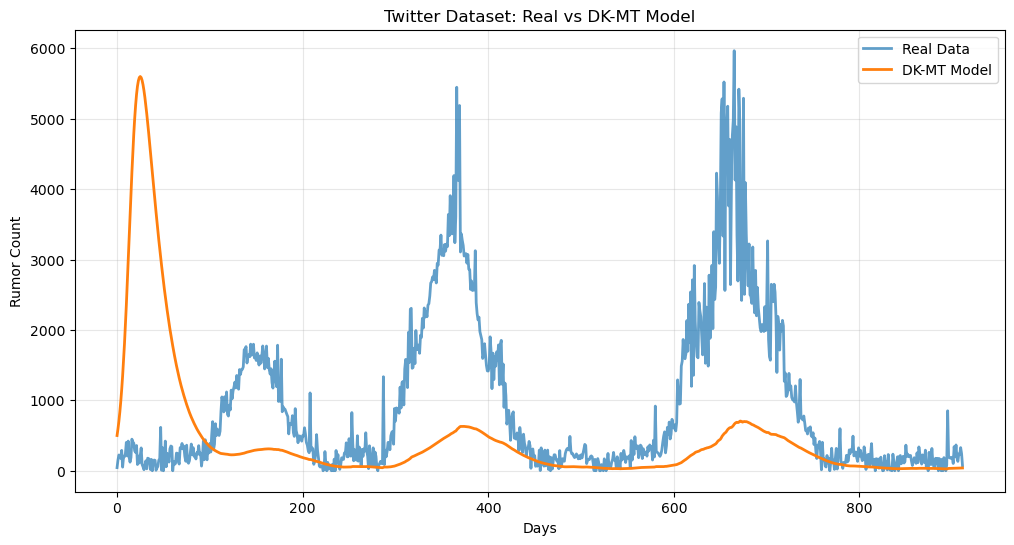

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def rk4_step(f, y, t, h):

    k1 = f(t, y)

    k2 = f(t + h/2, y + h*k1/2)

    k3 = f(t + h/2, y + h*k2/2)

    k4 = f(t + h, y + h*k3)

    return y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

def dk_mt_derivative(
    t,
    y,
    beta,
    alpha,
    kappa,
    N,
    lambda_func
):

    I, S, R = y

    forcing = kappa * lambda_func(t)

    dI_dt = -beta * (I * S) / N

    dS_dt = (
        beta * (I * S) / N
        - alpha * S * (S + R) / N
        + forcing
    )

    dR_dt = alpha * S * (S + R) / N

    return np.array([dI_dt, dS_dt, dR_dt])
    

def simulate_rumor_spread(
    y0,
    t_span,
    h,
    f_derivative,
    *args
):

    t_values = np.arange(
        t_span[0],
        t_span[1] + h,
        h
    )

    y_values = np.zeros(
        (len(t_values), len(y0))
    )

    y_values[0] = y0

    y_current = np.array(
        y0,
        dtype=float
    )
    
    f_wrapper = lambda t, y: f_derivative(
        t,
        y,
        *args
    )

    for i in range(1, len(t_values)):

        t = t_values[i - 1]

        # RK4 step
        y_next = rk4_step(
            f_wrapper,
            y_current,
            t,
            h
        )

        y_next = np.maximum(y_next, 0)

        total = np.sum(y_next)

        N = args[3]  # N is the 4th extra argument

        if total > 0:
            y_next = y_next * (N / total)

        y_values[i] = y_next

        y_current = y_next

    return t_values, y_values

def run_dataset(
    csv_path,
    rumor_column,
    title,
    beta,
    alpha,
    kappa
):
    
    df = pd.read_csv(csv_path)

    print("\nColumns in dataset:")
    print(df.columns)
    
    rumor_data = df[rumor_column].values
    h = 1.0

    days_to_simulate = len(rumor_data) - 1

    t_span = (0, days_to_simulate)

    N = 10000

    I0 = N - 1000
    S0 = 500
    R0 = 500

    y0 = [I0, S0, R0]
    
    days = np.arange(len(rumor_data))

    lambda_func = interp1d(
        days,
        rumor_data,
        kind='linear',
        fill_value="extrapolate"
    )
    
    print(f"\nRunning simulation for: {title}")

    t_values, y_values = simulate_rumor_spread(
        y0,
        t_span,
        h,
        dk_mt_derivative,
        beta,
        alpha,
        kappa,
        N,
        lambda_func
    )
    
    S_model = y_values[:, 1]
    
    plt.figure(figsize=(12, 6))

    plt.plot(
        t_values,
        rumor_data,
        label="Real Data",
        linewidth=2,
        alpha=0.7
    )

    plt.plot(
        t_values,
        S_model,
        label="DK-MT Model",
        linewidth=2
    )

    plt.title(title)

    plt.xlabel("Days")

    plt.ylabel("Rumor Count")

    plt.legend()

    plt.grid(True, alpha=0.3)

    plt.show()
    return t_values, rumor_data, S_model

# NEWS PARAMETERS
beta_news = 0.0983
alpha_news = 0.26829
kappa_news = 0.26892

# TWITTER PARAMETERS
beta_twitter = 0.1966
alpha_twitter = 0.0468
kappa_twitter = 0.00974

news_results = run_dataset(
    csv_path="news_dataset_fixed.csv",
    rumor_column="rumor_news",
    title="News Dataset: Real vs DK-MT Model",
    beta=beta_news,
    alpha=alpha_news,
    kappa=kappa_news
)

twitter_results = run_dataset(
    csv_path="twitter_dataset_fixed.csv",
    rumor_column="rumor_tweets",
    title="Twitter Dataset: Real vs DK-MT Model",
    beta=beta_twitter,
    alpha=alpha_twitter,
    kappa=kappa_twitter
)